Loading and Importing Libraries

In [3]:
install.packages("keras", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’




In [4]:
install.packages("BiocManager", repos = "https://cloud.r-project.org")
BiocManager::install("EBImage", ask = FALSE, update = FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'EBImage'

also installing the dependency ‘fftwtools’


Warning message in install.packages(...):
“installation of package ‘fftwtools’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘EBImage’ had non-zero exit status”


In [6]:
system("apt-get update -qq")
system("apt-get install -y libfftw3-dev")

In [9]:
install.packages("fftwtools", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [10]:
BiocManager::install("EBImage", ask = FALSE, update = FALSE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'EBImage'



In [12]:
install.packages("keras3", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘dotty’




In [32]:
install.packages("keras3", repos = "https://cloud.r-project.org")

library(keras3)

install_keras(
  backend = "tensorflow",
  python_version = "3.11"
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 methods overwritten by 'keras3':
  method                               from 
  as.data.frame.keras_training_history keras
  plot.keras_training_history          keras
  print.keras_training_history         keras
  r_to_py.R6ClassGenerator             keras


Attaching package: ‘keras3’


The following objects are masked from ‘package:keras’:

    %<-active%, %py_class%, activation_elu, activation_exponential,
    activation_gelu, activation_hard_sigmoid, activation_linear,
    activation_relu, activation_selu, activation_sigmoid,
    activation_softmax, activation_softplus, activation_softsign,
    activation_tanh, adapt, application_densenet121,
    application_densenet169, application_densenet201,
    application_efficientnet_b0, application_efficientnet_b1,
    application_efficientnet_b2, application_efficientnet_b3,
    application_efficientnet_b4, application_efficientnet_b5,
    app

ERROR: Error in path.expand(path): invalid 'path' argument


In [13]:
library(EBImage)
library(keras)

Reading Images


In [14]:
dir.create("/content/images")

In [15]:
files <- list.files(
  "/content",
  pattern = "\\.(jpg|jpeg|png|bmp|tif|tiff)$",
  full.names = TRUE,
  ignore.case = TRUE
)

file.rename(
  files,
  file.path("/content/images", basename(files))
)

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE

In [16]:
list.files("/content/images")

[1] "car1.jpg"   "car2.jpg"   "car3.jpg"   "car4.jpg"   "car5.jpg"  
 [6] "car6.jpg"   "plane1.jpg" "plane2.jpg" "plane3.jpg" "plane4.jpg"
[11] "plane5.jpg" "plane6.jpg"

In [17]:
setwd("/content/images")

In [18]:
getwd()

[1] "/content/images"

In [19]:
pics <- c(
  "car1.jpg",
  "car2.jpg",
  "car3.jpg",
  "car4.jpg",
  "car5.jpg",
  "car6.jpg",
  "plane1.jpg",
  "plane2.jpg",
  "plane3.jpg",
  "plane4.jpg",
  "plane5.jpg",
  "plane6.jpg"
)

mypic <- list()

for (i in 1:12) {
  mypic[[i]] <- readImage(pics[i])
}

In [20]:
length(mypic)

[1] 12

Exploring

In [21]:
print(mypic[[1]])

Image 
  colorMode    : Color 
  storage.mode : double 
  dim          : 671 298 3 
  frames.total : 3 
  frames.render: 1 

imageData(object)[1:5,1:6,1]
          [,1]      [,2]      [,3]      [,4]      [,5]      [,6]
[1,] 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569
[2,] 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569
[3,] 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569
[4,] 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569
[5,] 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569 0.7921569


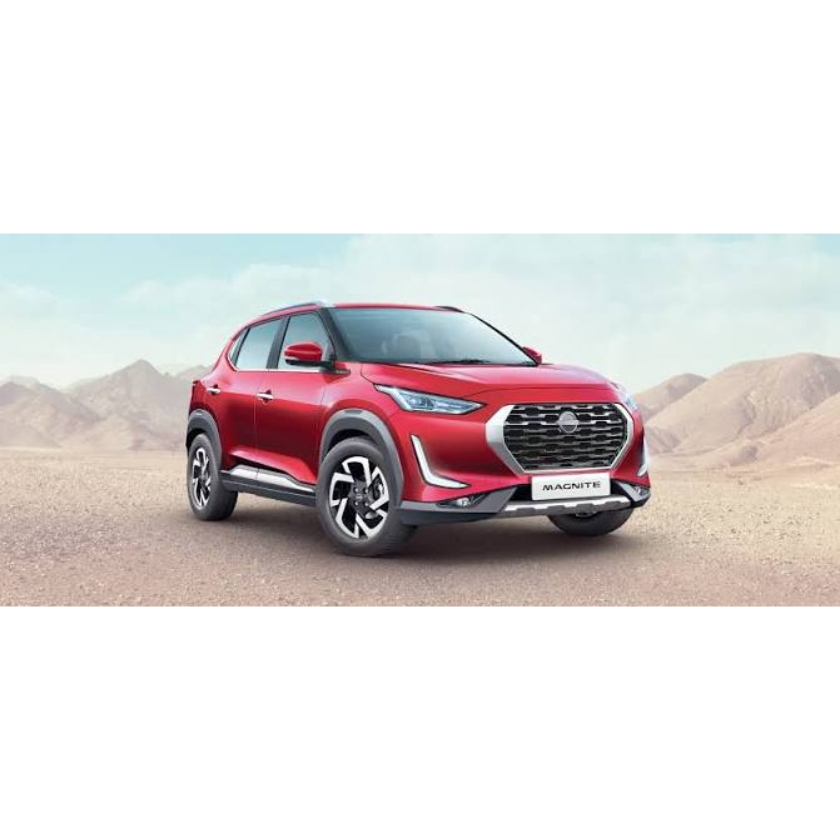

In [22]:
display(mypic[[1]])

In [23]:
summary(mypic[[1]])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.5922  0.7725  0.6938  0.9020  1.0000 

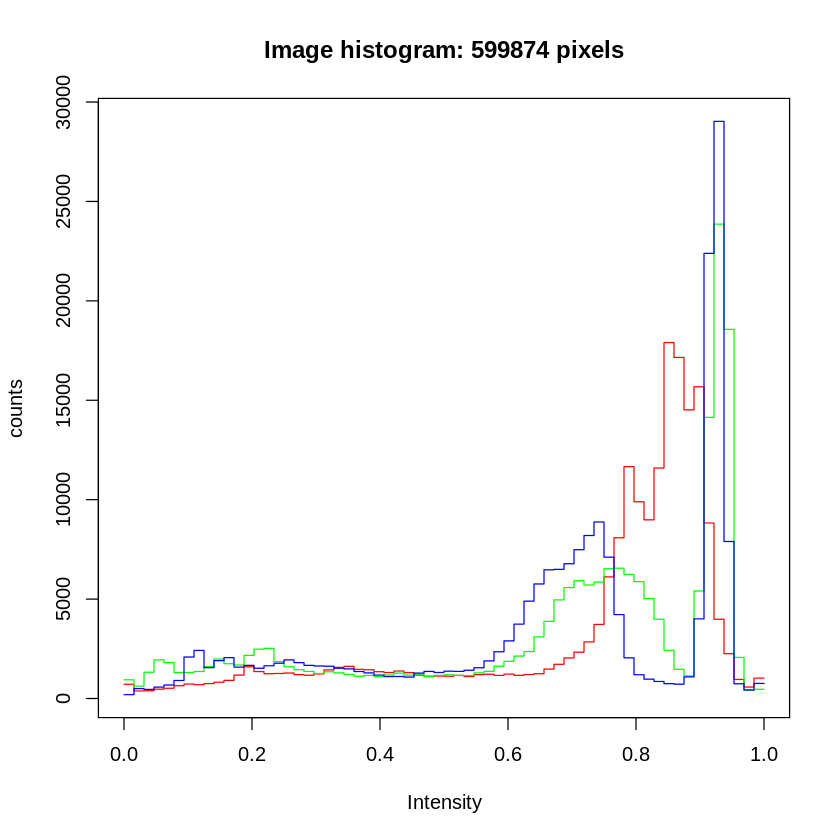

In [24]:
hist(mypic[[1]])

In [25]:
str(mypic)

List of 12
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:671, 1:298, 1:3] 0.792 0.792 0.792 0.792 0.792 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 671 298 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:480, 1:320, 1:3] 0.878 0.878 0.878 0.878 0.878 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 480 320 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:638, 1:480, 1:3] 0.125 0.125 0.125 0.125 0.125 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 638 480 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:597, 1:335, 1:3] 0.0784 0.0745 0.0745 0.0706 0.0745 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 597 335 3
 $ :Formal class 'Image' [package "EBImage"] with 2 slots
  .. ..@ .Data    : num [1:738, 1:414, 1:3] 1 1 1 1 1 1 1 1 1 1 ...
  .. ..@ colormode: int 2
  .. ..$ dim: int [1:3] 738 414 3
 $ :Formal cla

Resize

In [26]:
for (i in 1:12) {
  mypic[[i]] <- resize(mypic[[i]], 28, 28)
}

In [27]:
dim(mypic[[1]])

[1] 28 28  3

Reshape

In [29]:
for (i in 1:12) {
  mypic[[i]] <- array_reshape(mypic[[i]], dim = c(28, 28, 3))
}

Raw Bind

In [43]:
trainx <- NULL

for (i in c(1:5, 7:11)) {
  trainx <- rbind(trainx, mypic[[i]])
}

str(trainx)

testx <- rbind(mypic[[6]], mypic[[12]])

# Labels: 0 = plane, 1 = car

trainy <- c(0, 0, 0, 0, 0, 1, 1, 1, 1, 1)

testy <- c(0, 1)

 num [1:10, 1:2352] 0.788 0.878 0.141 0.101 1 ...


One Hot Encoding

In [44]:
trainLabels <- to_categorical(trainy)
testLabels <- to_categorical(testy)

Model

In [45]:
model <- keras_model_sequential() %>%
  layer_dense(units = 256, activation = "relu", input_shape = c(2352)) %>%
  layer_dense(units = 128, activation = "relu") %>%
  layer_dense(units = 2, activation = "softmax")

summary(model)

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                   │ (None, 256)              │       602,368 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_4 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_5 (Dense)                   │ (None, 2)                │           258 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘
 Total params: 635,522 (2.42 MB)
 Trainable params: 635,522 (2.42 MB)
 Non-trainable params: 0 (0.00 B)


In [46]:
2352*256

[1] 602112

In [47]:
602112+256

[1] 602368

In [48]:
128*256

[1] 32768

In [49]:
32768+128

[1] 32896

Compile

In [50]:
model %>%
  compile(
    loss = "categorical_crossentropy",
    optimizer = optimizer_rmsprop(),
    metrics = c("accuracy")
  )

Fit Model

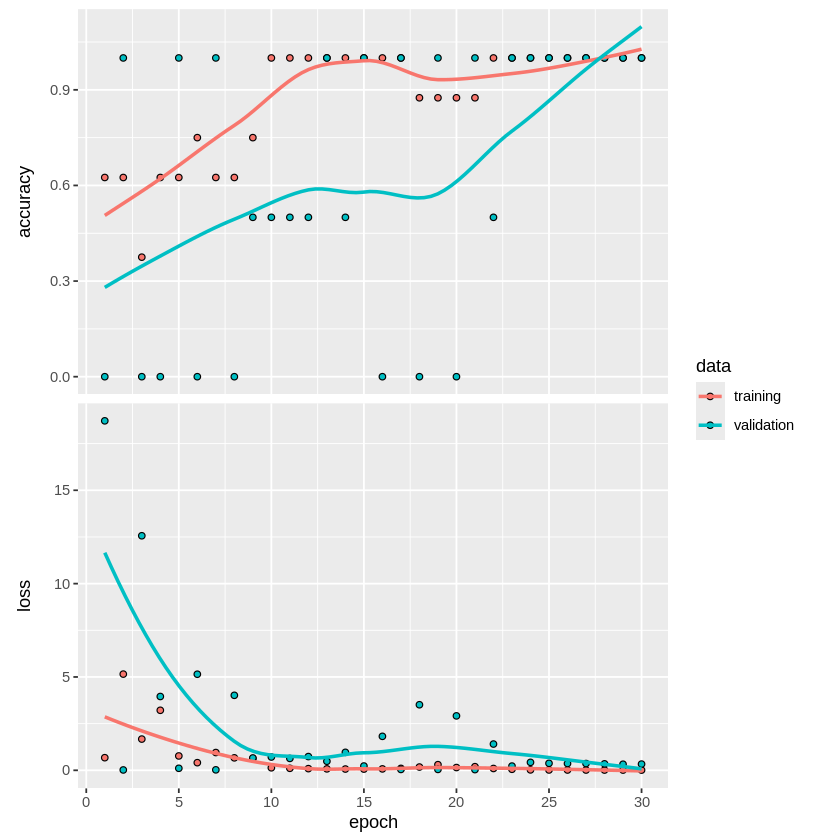

In [51]:
# Fit Model

history <- model %>%
  fit(
    trainx,
    trainLabels,
    epochs = 30,
    batch_size = 32,
    validation_split = 0.2
  )

plot(history)

Evaulation and Prediction on train data

In [52]:
model %>% evaluate(trainx, trainLabels)

prob <- model %>% predict(trainx)

pred <- max.col(prob) - 1

table(Predicted = pred, Actual = trainy)

cbind(
  prob,
  Predicted = pred,
  Actual = trainy
)

$accuracy
[1] 1

$loss
[1] 0.07485192

         Actual
Predicted 0 1
        0 5 0
        1 0 5

,,Predicted,Actual
0.9986777306,0.001322366,0,0
0.9964919686,0.003507971,0,0
0.9771755338,0.022824557,0,0
0.9863568544,0.013643090,0,0
0.9985328317,0.001467123,0,0
0.0294387266,0.970561266,1,1
0.0077222232,0.992277741,1,1
0.0009622213,0.999037802,1,1
0.1226324067,0.877367616,1,1
0.4148943126,0.585105717,1,1


Evaluation & Prediction - Test Data

In [53]:
model %>% evaluate(testx, testLabels)

prob <- model %>% predict(testx)

pred <- max.col(prob) - 1

table(Predicted = pred, Actual = testy)

cbind(
  prob,
  Predicted = pred,
  Actual = testy
)

$accuracy
[1] 1

$loss
[1] 0.1400038

         Actual
Predicted 0 1
        0 1 0
        1 0 1

,,Predicted,Actual
0.9843928,0.01560729,0,0
0.2322394,0.76776063,1,1


Testing Accuracy

In [54]:
test_result <- model %>% evaluate(testx, testLabels, verbose = 0)

test_result

$accuracy
[1] 1

$loss
[1] 0.1400038

Show the final predictions

In [55]:
data.frame(
  Image = c("car6.jpg", "plane6.jpg"),
  Predicted = ifelse(pred == 1, "Car", "Plane"),
  Actual = ifelse(testy == 1, "Car", "Plane")
)

Image,Predicted,Actual
<chr>,<chr>,<chr>
car6.jpg,Plane,Plane
plane6.jpg,Car,Car


Calculate prediction accuracy manually

In [56]:
accuracy <- mean(pred == testy)

accuracy

[1] 1

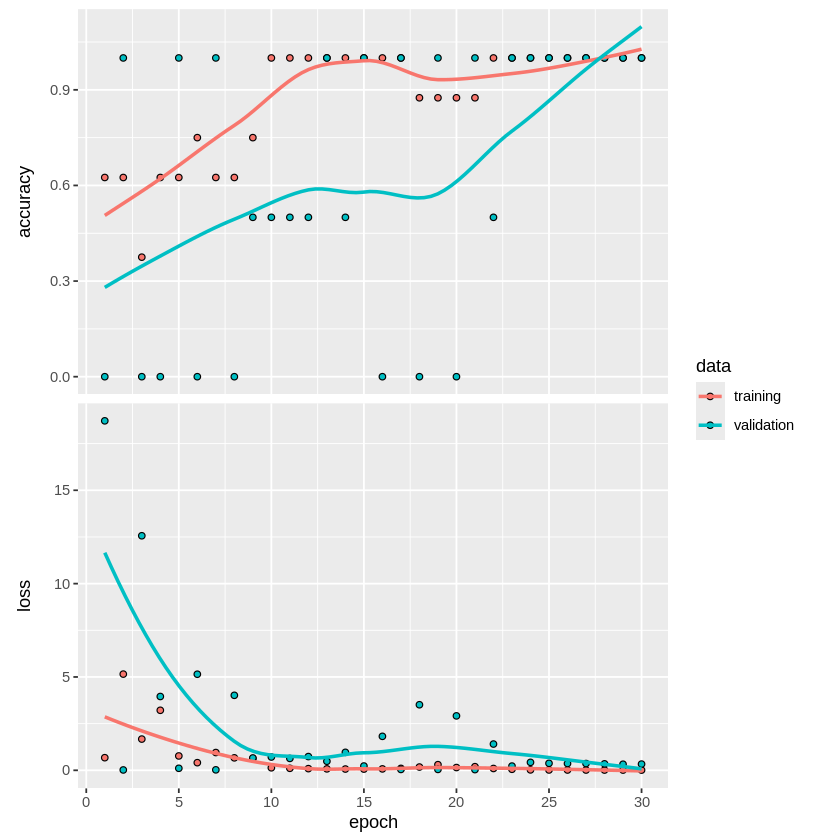

In [57]:
plot(history)

The experiment successfully demonstrated image classification using R, EBImage, and Keras. The images were resized and reshaped, labelled as car (1) and plane (0), and used to train a neural network model. The model was compiled, trained, and evaluated on both training and test data. The predictions were then compared with the actual labels to measure the model's performance.